# Discrete Fourier Series (DFS) — Manual Implementation (No FFT)

**Course:** Signals / DSP  
**Homework:** DFS by correlation / inner products (`np.sum` / `np.dot`)  
**Student:** *(Cruces Nuñez Claudia Meera; Tellez Olmedo Eduardo Ivan)*  
**Date:** *(03/10/2026)*

---

## Objective

Implement the **Discrete Fourier Series (DFS)** for **periodic discrete-time** signals.

You must:

1. Construct **three** periodic discrete signals (one period only).
2. Compute DFS coefficients **manually** using the definition (correlation / inner product).
3. Reconstruct each signal from its coefficients.
4. Compare original vs reconstructed signals.
5. Report reconstruction error.

---

## Restrictions (IMPORTANT)

 Allowed:
- `numpy`, `matplotlib`
- `np.sum`, `np.dot`
- `np.exp`, complex numbers, loops (if you want)

 Not allowed:
- `np.fft.fft`, `np.fft.ifft`, or any FFT/DFT helper
- Any library function that directly returns Fourier coefficients


## DFS Definitions (use these)

We work with one period of a discrete-time periodic signal:
- Period: $$N$$
- Samples: $$n = 0,1,\dots,N-1$$
- Signal values: $$x[n]$$

### Complex exponential basis
$$
\phi_k[n] = e^{j\frac{2\pi}{N}kn},\quad k=0,1,\dots,N-1
$$

### Analysis (coefficients)
$$
X[k] = \frac{1}{N}\sum_{n=0}^{N-1} x[n]\;e^{-j\frac{2\pi}{N}kn}
$$

### Synthesis (reconstruction)
$$
\hat{x}[n] = \sum_{k=0}^{N-1} X[k]\;e^{j\frac{2\pi}{N}kn}
$$

### Reconstruction error (RMSE)
$$
\mathrm{RMSE} = \sqrt{\frac{1}{N}\sum_{n=0}^{N-1}\left|x[n]-\hat{x}[n]\right|^2}
$$

**Implementation requirement:** compute the sums using `np.sum` or `np.dot`.


In [16]:
# === Imports ===
import numpy as np
import matplotlib.pyplot as plt

# Make plots a bit larger for readability (optional)
plt.rcParams["figure.figsize"] = (10, 4)

# For reproducibility (only matters if you add noise later)
np.random.seed(0)


## Deliverables (what you must submit)

For each of the three signals (A, B, C), include:

1) A plot of the signal over one period: $$x[n]$$, $$n=0..N-1$$  
2) A stem/bar plot of the magnitude spectrum: $$|X[k]|$$  
3) A plot of the phase spectrum: $$angle X[k]$$  
4) A plot comparing $$x[n]$$ and $$\hat{x}[n]$$ over one period  
5) RMSE value and 2–4 sentences of interpretation

---

## Signals to analyze

You must implement all DFS for **three different periods**:
N1 = 16
N2 = 32
N3 = 64

### Signal A — Square wave
One period definition:
- $$x_A[n] = 1$$ for $$0 \le n < N_1/2$$
- $$x_A[n] = -1$$ for $$N_1/2 \le n < N_1$$

### Signal B — Triangle wave
Build a discrete triangle over one period, peak amplitude 1 (or rescale to $$[-1,1]$$).

#Signal C — Sum of sinusoids
$$
x_C[n] =
0.8\cos\left(2\pi\frac{1}{N}n\right)
+ 0.4\sin\left(2\pi\frac{2}{N}n + 0.3\right)
+ 0.2\cos\left(2\pi\frac{3}{N}n - 0.8\right)
$$

In [17]:
# === TODO 1: DFS (Analysis) ===
def dfs(x):
    """
    Compute DFS coefficients X[k] for a single-period signal x[n].
    X[k] = (1/N) * sum_{n=0}^{N-1} x[n] * exp(-j*2*pi*k*n/N)
    """
    x = np.asarray(x)
    N = len(x)                          # 1) periodo
    n = np.arange(N)                    # 2) n = 0, 1, ..., N-1
    X = np.zeros(N, dtype=complex)      # aquí guardamos los N coeficientes

    for k in range(N):                  # 3) un coeficiente por cada k
        E = np.exp(-1j * 2 * np.pi * k * n / N)   # las N exponenciales E_n
        X[k] = (1 / N) * np.sum(x * E)            # multiplica y suma
    return X                            # 4)


# === TODO 2: Inverse DFS (Synthesis) ===
def idfs(X):
    """
    Reconstruct x_hat[n] from DFS coefficients X[k].
    x_hat[n] = sum_{k=0}^{N-1} X[k] * exp(+j*2*pi*k*n/N)
    """
    X = np.asarray(X)
    N = len(X)                          # 1) periodo
    k = np.arange(N)                    # 2) k = 0, 1, ..., N-1
    x_hat = np.zeros(N, dtype=complex)  # aquí guardamos la señal reconstruida

    for n in range(N):                  # 3) una muestra por cada n
        E = np.exp(1j * 2 * np.pi * k * n / N)    # exponenciales con signo +
        x_hat[n] = np.sum(X * E)                  # sin el 1/N
    return x_hat                        # 4)


def rmse(x, x_hat):
    """Root-mean-square error over one period."""
    x = np.asarray(x)
    x_hat = np.asarray(x_hat)
    N = len(x)
    return np.sqrt((1.0 / N) * np.sum(np.abs(x - x_hat) ** 2)) 


In [18]:
# === TODO 3: Build the three signals (one period only) ===

# Signal A: square wave, N1 = 16
N1 = 16
n1 = np.arange(N1)
xA = np.where(n1 < N1 // 2, 1.0, -1.0)

# Signal B: triangle wave, N2 = 32
N2 = 32
n2 = np.arange(N2)
xB = 1 - 4 * np.abs(n2 - N2 / 2) / N2

# Signal C: sum of sinusoids, N3 = 64
N3 = 64
n3 = np.arange(N3)
xC = (0.8 * np.cos(2 * np.pi * 1 / N3 * n3)
      + 0.4 * np.sin(2 * np.pi * 2 / N3 * n3 + 0.3)
      + 0.2 * np.cos(2 * np.pi * 3 / N3 * n3 - 0.8))

# Comprobación rápida
print("xA =", xA)
print("xB =", xB)
print("xC[0] =", round(xC[0], 4))


xA = [ 1.  1.  1.  1.  1.  1.  1.  1. -1. -1. -1. -1. -1. -1. -1. -1.]
xB = [-1.    -0.875 -0.75  -0.625 -0.5   -0.375 -0.25  -0.125  0.     0.125
  0.25   0.375  0.5    0.625  0.75   0.875  1.     0.875  0.75   0.625
  0.5    0.375  0.25   0.125  0.    -0.125 -0.25  -0.375 -0.5   -0.625
 -0.75  -0.875]
xC[0] = 1.0575


## Helper plotting template (use or modify)

You may use `plt.stem` for discrete plots.  
When plotting phase, you can use `np.angle(X)` (optionally `np.unwrap`).

**Note:** Small imaginary parts in `x_hat` may appear due to numerical precision.  
If so, compare against `np.real(x_hat)` and report that you took the real part.


Signal A (square): N=16, RMSE=3.146312e-15


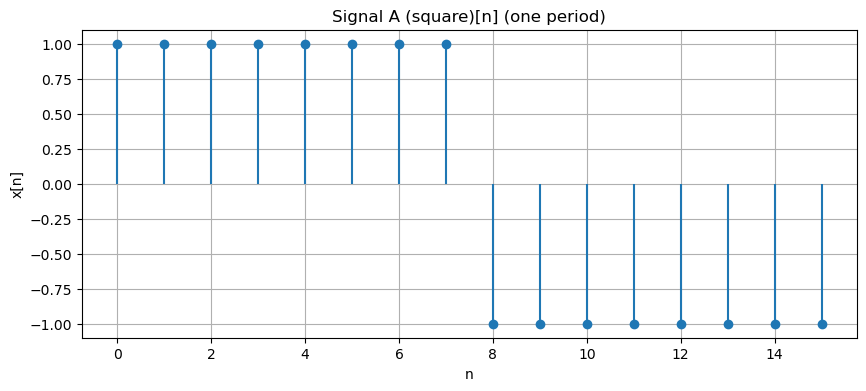

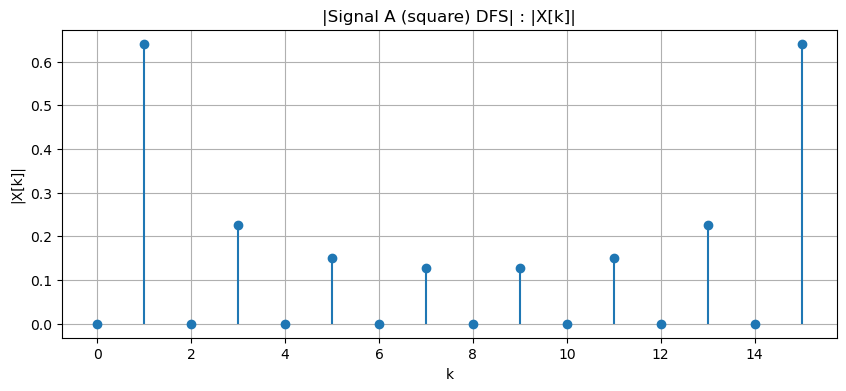

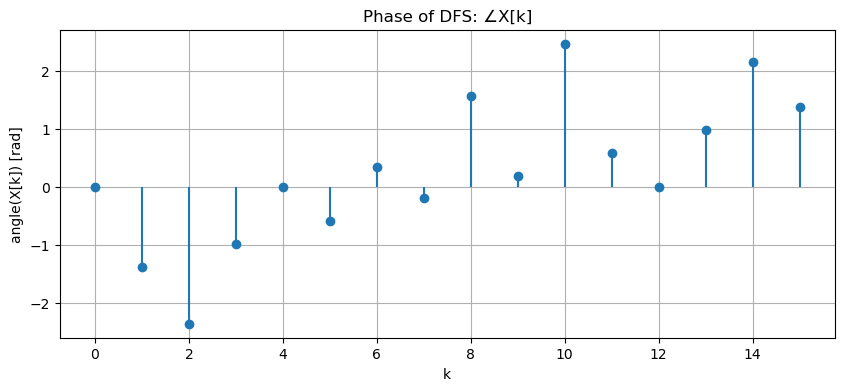

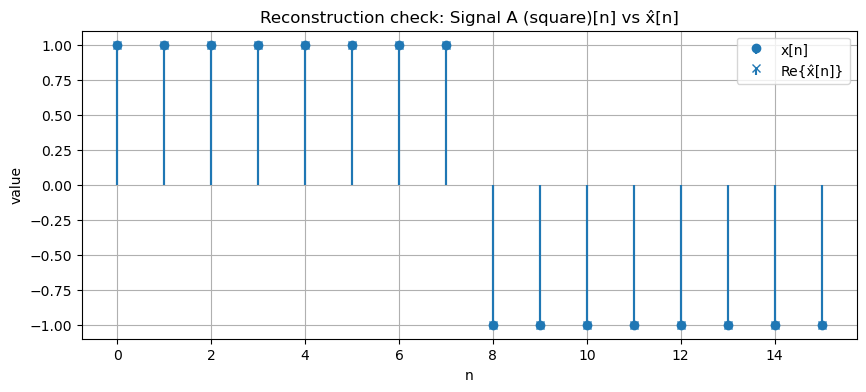

Signal B (triangle): N=32, RMSE=2.785711e-15


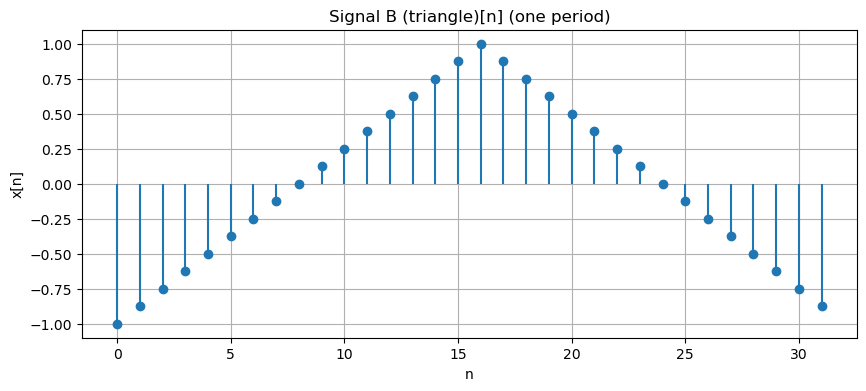

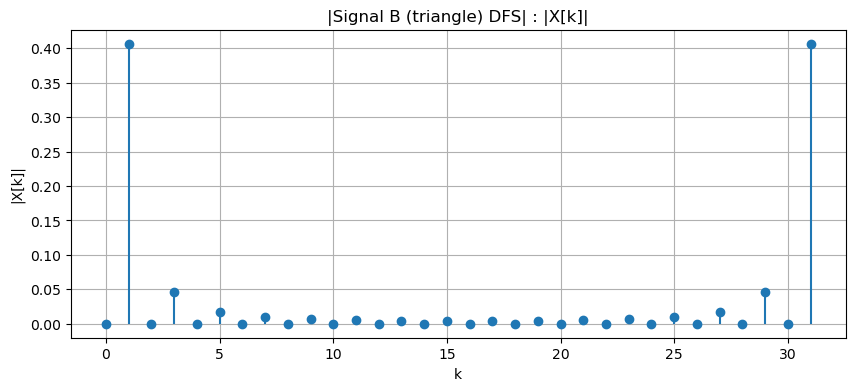

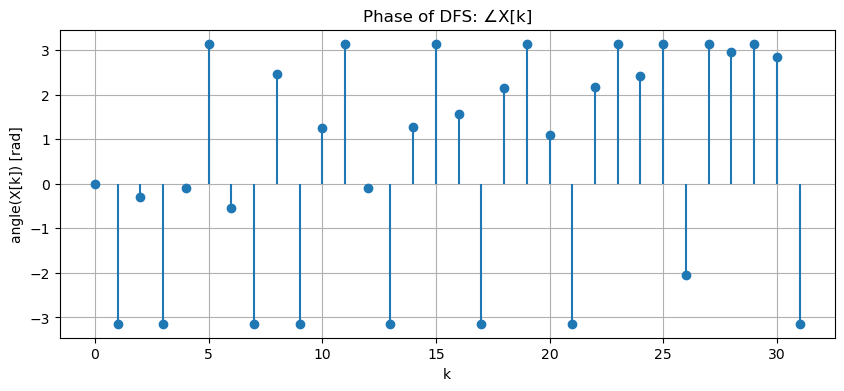

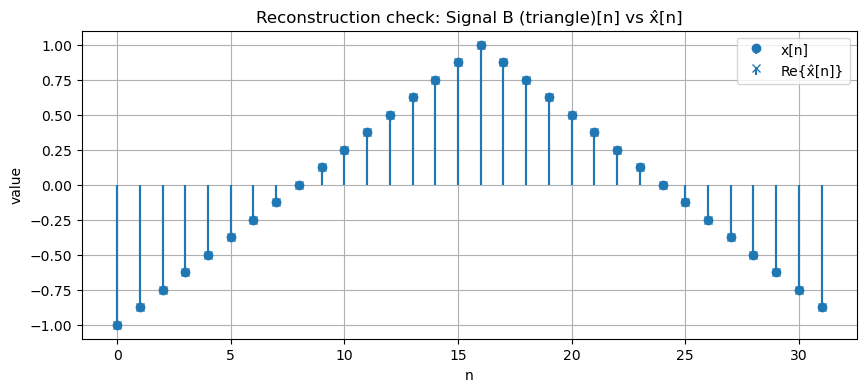

Signal C (sum of sinusoids): N=64, RMSE=7.337995e-15


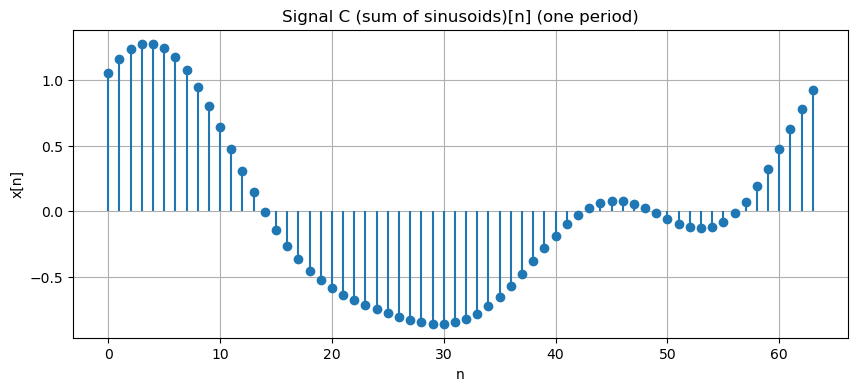

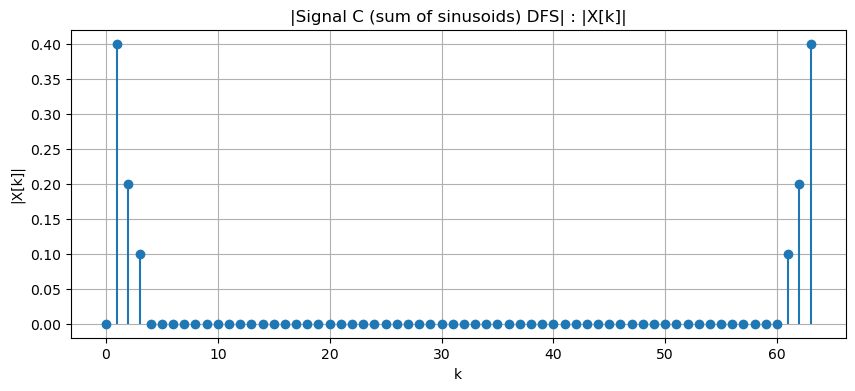

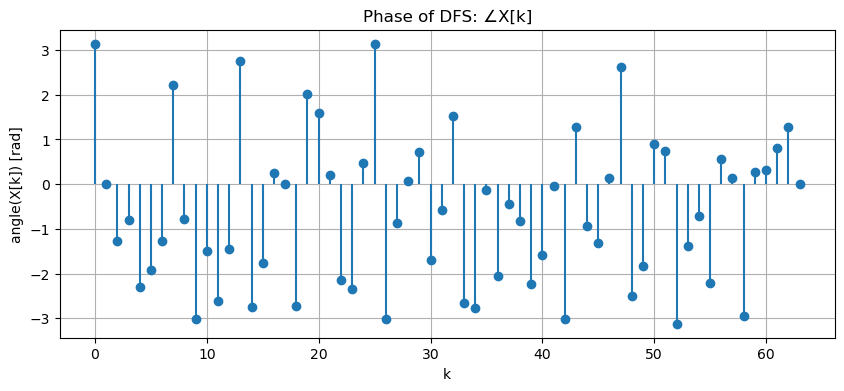

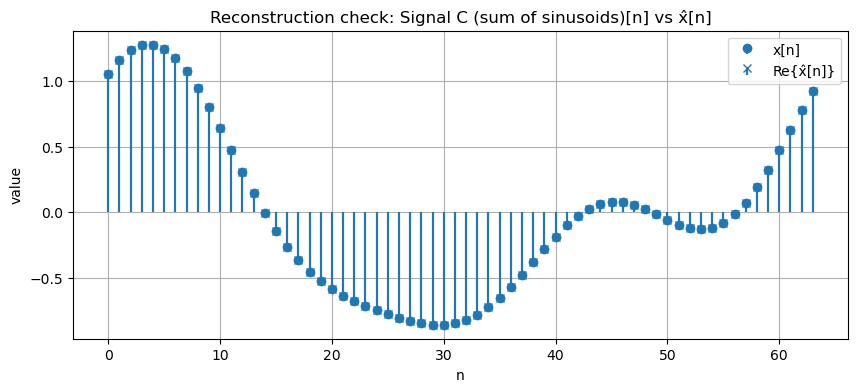

In [19]:
def analyze_signal(x, name="x"):
    """Compute DFS, reconstruct, plot, and print RMSE for one period."""
    x = np.asarray(x)
    N = len(x)
    n = np.arange(N)

    # --- DFS / IDFS ---
    X = dfs(x)
    x_hat = idfs(X)

    # --- Error ---
    e = rmse(x, x_hat)
    print(f"{name}: N={N}, RMSE={e:.6e}")

    # --- Plots: time domain ---
    plt.figure()
    plt.stem(n, np.real(x), basefmt=" ")
    plt.title(f"{name}[n] (one period)")
    plt.xlabel("n"); plt.ylabel("x[n]")
    plt.grid(True)
    plt.show()

    # --- Plots: magnitude spectrum ---
    k = np.arange(N)
    plt.figure()
    plt.stem(k, np.abs(X), basefmt=" ")
    plt.title(f"|{name} DFS| : |X[k]|")
    plt.xlabel("k"); plt.ylabel("|X[k]|")
    plt.grid(True)
    plt.show()

    # --- Plots: phase spectrum ---
    plt.figure()
    plt.stem(k, np.angle(X), basefmt=" ")
    plt.title(f"Phase of DFS: ∠X[k]")
    plt.xlabel("k"); plt.ylabel("angle(X[k]) [rad]")
    plt.grid(True)
    plt.show()

    # --- Plots: reconstruction ---
    plt.figure()
    plt.stem(n, np.real(x), basefmt=" ", markerfmt="o", label="x[n]")
    plt.stem(n, np.real(x_hat), basefmt=" ", markerfmt="x", label="Re{x̂[n]}")

    plt.title(f"Reconstruction check: {name}[n] vs x̂[n]")
    plt.xlabel("n"); plt.ylabel("value")
    plt.grid(True)
    plt.legend()
    plt.show()

    return X, x_hat


# === TODO 4: Run analysis for A, B, C ===
# Uncomment when you have implemented dfs/idfs and signals.

XA, xA_hat = analyze_signal(xA, name="Signal A (square)")
XB, xB_hat = analyze_signal(xB, name="Signal B (triangle)")
XC, xC_hat = analyze_signal(xC, name="Signal C (sum of sinusoids)")


## Short reflection (write your answers here)

For each signal:

- How many coefficients (roughly) are “dominant” in magnitude?
- Does the phase look structured or noisy? Why?
- If you keep only the largest M coefficients (optional extension), what happens in reconstruction?

*(Write 2–4 sentences per signal.)*


### Signal A — Square wave (N = 16)
**RMSE = ...** (prácticamente cero; el valor se debe solo al redondeo de punto flotante).

Solo los coeficientes impares son distintos de cero y su magnitud decae aproximadamente como 1/k, por lo que los dominantes son el par k = 1, 15 (|X| ≈ 0.64), aunque los demás impares siguen aportando de forma apreciable. La fase de los coeficientes no nulos es estructurada: varía linealmente con k (πk/16 − π/2), mientras que en los k pares aparece como "ruido" porque ahí X[k] ≈ 1e-16 y `np.angle` se evalúa sobre puro error numérico. Si se conservaran solo los M coeficientes más grandes, la reconstrucción tendría oscilaciones cerca de los saltos (fenómeno de Gibbs), ya que la cuadrada necesita muchos armónicos para formar sus discontinuidades.

### Signal B — Triangle wave (N = 32)
**RMSE = ...** (prácticamente cero; el valor se debe solo al redondeo de punto flotante).

Solo los coeficientes impares son distintos de cero y decaen como 1/k², mucho más rápido que en la cuadrada, de modo que el par k = 1, 31 (|X| ≈ 0.41) concentra casi toda la energía de la señal. Todos los coeficientes no nulos son reales y negativos por la simetría de la señal, así que la fase es constante e igual a ±π (estructurada); en los k donde X[k] = 0 la fase vuelve a ser ruido numérico. Con pocos coeficientes la reconstrucción ya es muy buena, porque la triangular es una señal continua sin saltos.

### Signal C — Sum of sinusoids (N = 64)
**RMSE = ...** (prácticamente cero; el valor se debe solo al redondeo de punto flotante).

Solo 6 de los 64 coeficientes son distintos de cero (k = 1, 2, 3 y sus espejos 63, 62, 61), uno por cada senoidal, con magnitud igual a la mitad de su amplitud (0.4, 0.2 y 0.1). La fase en esos coeficientes es estructurada y reproduce la fase de cada componente (0, 0.3 − π/2 y −0.8 rad), con signo opuesto en los espejos, mientras que en el resto es ruido numérico. Conservando solo esos 6 coeficientes (M = 6) la reconstrucción es exacta, porque la señal no contiene ninguna otra frecuencia.